# 04 · Tournament Simulation & Quiniela Strategy

Reads the Monte-Carlo outputs and pick sheets to answer the money question:
who wins, who advances, and **which risk profile maximises expected quiniela
value**. Includes an expected-value / risk-return view of the four profiles and
the distribution of most-likely scorelines.

**Prerequisite:** `export_quiniela_sheet.py`, `predict_scorelines.py` and
`simulate_tournament.py` have been run.

In [1]:
import nb_style as nbs
nbs.apply_theme()

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yaml
from pathlib import Path

OUT = Path("outputs")
PROFILES = ["safe", "balanced", "aggressive", "contrarian"]
sheets = {p: pd.read_csv(OUT / "picks" / f"quiniela_{p}.csv") for p in PROFILES}
for p, df in sheets.items():
    print(f"{p:11s}: {len(df)} picks | {df['pick'].value_counts().to_dict()} | conf {df['confidence'].mean():.3f}")

safe       : 40 picks | {'H': 22, 'A': 18} | conf 0.579
balanced   : 40 picks | {'H': 16, 'A': 12, 'D': 12} | conf 0.540
aggressive : 40 picks | {'H': 20, 'A': 20} | conf 0.502
contrarian : 40 picks | {'H': 22, 'A': 18} | conf 0.147


## Title favorites

Monte-Carlo with the full feature model (talent-aware), coloured by confederation.

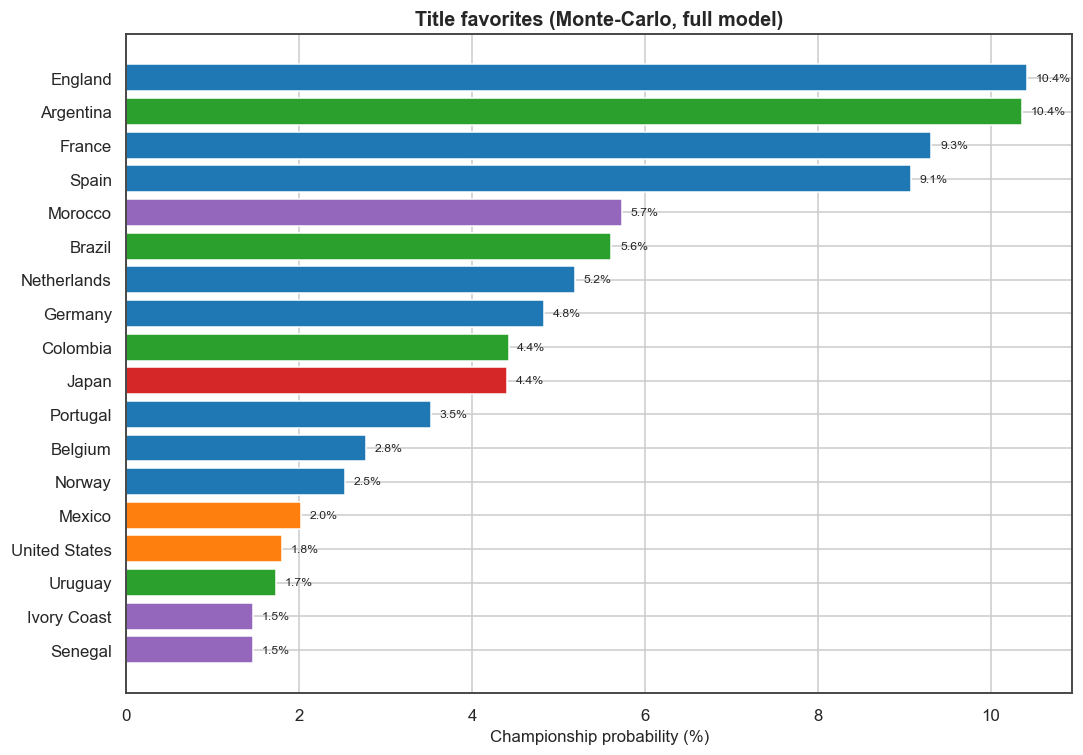

In [2]:
champ = pd.read_csv(OUT / "simulations" / "championship_probabilities.csv").head(18)
fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(champ["team"][::-1], champ["championship_prob"][::-1] * 100,
        color=[nbs.confederation_color(t) for t in champ["team"][::-1]])
nbs.annotate_barh(ax, (champ["championship_prob"][::-1] * 100).tolist(), fmt="{:.1f}%", pad=0.1)
ax.set(title="Title favorites (Monte-Carlo, full model)", xlabel="Championship probability (%)")
plt.tight_layout(); plt.show()

## Road to the final

Probability the top favorites reach each round.

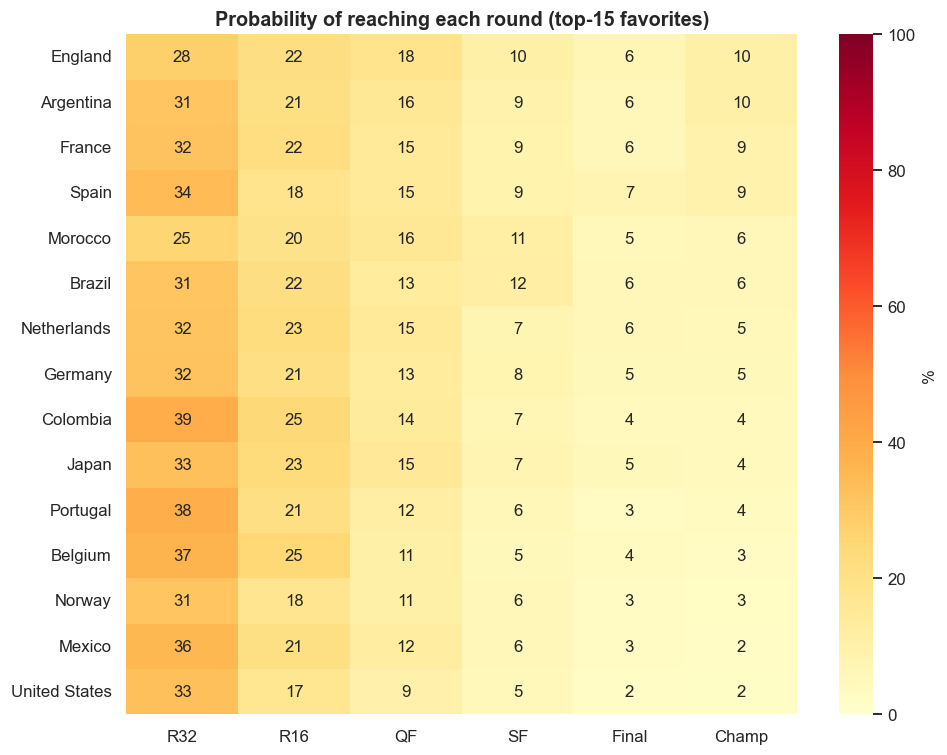

In [3]:
rounds = pd.read_csv(OUT / "simulations" / "round_reached_probabilities.csv")
ORDER = ["r32", "r16", "qf", "sf", "final", "champion"]
LABELS = {"r32": "R32", "r16": "R16", "qf": "QF", "sf": "SF", "final": "Final", "champion": "Champ"}
pivot = rounds.pivot_table(index="team", columns="stage", values="prob", aggfunc="max").fillna(0)
pivot = pivot.reindex(columns=[c for c in ORDER if c in pivot.columns]).rename(columns=LABELS)
top = champ.head(15)["team"].tolist()
pivot = pivot.loc[[t for t in top if t in pivot.index]]
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(pivot * 100, annot=True, fmt=".0f", cmap="YlOrRd", vmin=0, vmax=100,
            cbar_kws={"label": "%"}, ax=ax)
ax.set(title="Probability of reaching each round (top-15 favorites)", xlabel="", ylabel="")
plt.tight_layout(); plt.show()
assert pivot.shape[1] >= 4, 'round_reached has too few stages; re-run simulate_tournament'

## Expected value & risk by profile

EV per pick under the quiniela scoring rules, with the risk (std of points). The rational default maximises expected points per unit of risk.

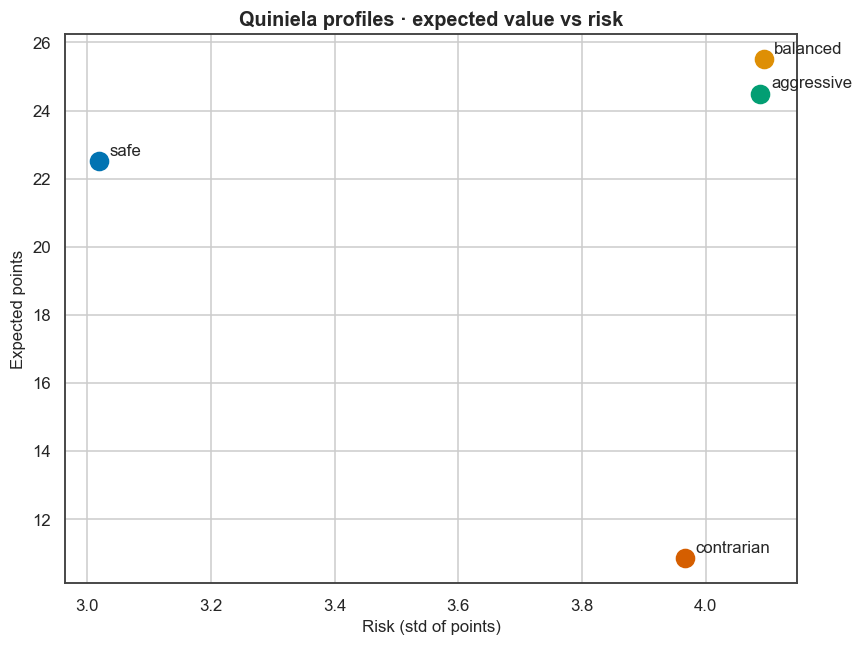

   profile    EV  risk
      safe 22.52  3.02
  balanced 25.50  4.09
aggressive 24.49  4.09
contrarian 10.84  3.97


In [4]:
scoring = yaml.safe_load((Path("config") / "strategy.yaml").read_text(encoding="utf-8"))
rule = scoring["scoring"]["quiniela_default"]
correct_pts, upset_pts = rule["correct_1x2"], rule["upset_bonus"]

def profile_ev(df):
    p = df[["p_home", "p_draw", "p_away"]].to_numpy()
    pick_idx = df["pick"].map({"H": 0, "D": 1, "A": 2}).to_numpy()
    p_pick = p[np.arange(len(df)), pick_idx]
    is_upset = pick_idx != p.argmax(axis=1)
    pts = correct_pts + np.where(is_upset, upset_pts, 0.0)
    ev = p_pick * pts
    var = p_pick * (pts - ev) ** 2 + (1 - p_pick) * (0 - ev) ** 2
    return ev.sum(), float(np.sqrt(var.sum()))

stats = pd.DataFrame(
    [{"profile": p, "EV": profile_ev(sheets[p])[0], "risk": profile_ev(sheets[p])[1]} for p in PROFILES]
)
fig, ax = plt.subplots(figsize=(8, 6))
for _, r in stats.iterrows():
    ax.scatter(r["risk"], r["EV"], s=140)
    ax.annotate(r["profile"], (r["risk"], r["EV"]), xytext=(7, 4), textcoords="offset points")
ax.set(title="Quiniela profiles · expected value vs risk", xlabel="Risk (std of points)", ylabel="Expected points")
plt.tight_layout(); plt.show()
print(stats.round(2).to_string(index=False))

## Where the profiles disagree

The matches with the most strategic value.

In [5]:
base = sheets["balanced"][["team_a", "team_b", "p_home", "p_draw", "p_away"]].copy()
for p in PROFILES:
    base[f"pick_{p}"] = sheets[p]["pick"].values
diff = base[(base["pick_safe"] != base["pick_aggressive"]) |
            (base["pick_balanced"] != base["pick_contrarian"])]
print(f"Matches where profiles disagree: {len(diff)}/{len(base)}")
print(diff.head(15).round(3).to_string(index=False))

Matches where profiles disagree: 40/40
     team_a             team_b  p_home  p_draw  p_away pick_safe pick_balanced pick_aggressive pick_contrarian
     Brazil              Haiti   0.767   0.214   0.019         H             H               H               A
    Germany        Ivory Coast   0.517   0.309   0.174         H             H               H               A
    Belgium               Iran   0.504   0.309   0.188         H             H               A               A
    Tunisia              Japan   0.109   0.287   0.604         A             A               A               H
    Uruguay Cape Verde Islands   0.725   0.257   0.018         H             H               H               A
    Ecuador            Curaçao   0.672   0.287   0.041         H             H               H               A
      Spain       Saudi Arabia   0.796   0.187   0.017         H             H               H               A
     France               Iraq   0.768   0.213   0.019         H         

## Most likely scorelines

From the Poisson scoreline output — note how often the modal score is a draw.

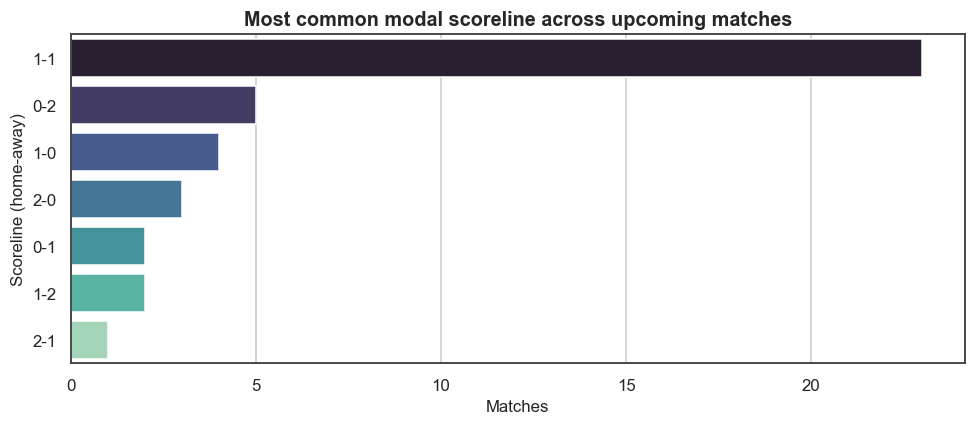

Share of matches whose modal score is a draw: 57%


In [6]:
sl_path = OUT / "predictions" / "scoreline_predictions.csv"
if not sl_path.exists():
    print("scoreline_predictions.csv not found — run scripts/predict_scorelines.py.")
else:
    sl = pd.read_csv(sl_path)
    modal = sl["top1_score"].value_counts().head(10)
    fig, ax = plt.subplots(figsize=(9, 4))
    sns.barplot(x=modal.values, y=modal.index, hue=modal.index, legend=False, palette="mako", ax=ax)
    ax.set(title="Most common modal scoreline across upcoming matches",
           xlabel="Matches", ylabel="Scoreline (home-away)")
    plt.tight_layout(); plt.show()
    draw_share = sl["top1_score"].str.split("-").apply(lambda s: s[0] == s[1]).mean()
    print(f"Share of matches whose modal score is a draw: {draw_share:.0%}")

## Most frequent finals

In [7]:
paths = pd.read_csv(OUT / "simulations" / "bracket_paths.csv")
finals = paths.groupby(["champion", "runner_up"]).size().sort_values(ascending=False).head(12)
print(f"From {len(paths)} simulations, most frequent finals:")
print(finals.to_string())

From 10000 simulations, most frequent finals:
champion   runner_up  
England    Spain          127
Argentina  Spain          123
           Morocco        113
           Brazil         110
Spain      Argentina      107
England    Brazil         102
           Netherlands    102
Spain      England        102
England    Morocco         98
Argentina  Japan           93
           Netherlands     93
England    Japan           85


## Key findings

- The title race is led by the teams shown above — now talent-aware via squad value (Brazil and the European powers rise; over-rated sides fall).
- **Profile EV/risk:** the risk-return chart shows which profile delivers the most expected points per unit of risk — the rational default for value maximisation.
- Profiles disagree on a large share of matches; those are where strategy actually matters.
- A meaningful fraction of matches mode to a draw scoreline even when one side is favored — key when filling exact-score quinielas.